# Week 5 | Mid-review: the data audit
**Team No. 4 · 24ADI204**

This notebook consolidates the cleaned dataset and initial findings for the review.
It prepares the evidence for presentation; it does not claim faculty review has taken place.
The Week 1–4 notebooks retain the complete EDA and cleaning rationale.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p/'Source_Code'/'attrition_lab.py').exists() or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None: raise FileNotFoundError('Open this notebook inside DSV_PROJECT')
sys.path.insert(0,str(ROOT/'Source_Code'))
from attrition_lab import load_raw, clean_data, rate_table
raw=load_raw(); clean=clean_data(raw)
pd.set_option('display.max_columns',12)

In [2]:
display(pd.DataFrame([{'raw_rows':len(raw),'raw_columns':raw.shape[1],
    'exact_duplicates':int(raw.duplicated().sum()),'raw_missing_cells':int(raw.isna().sum().sum()),
    'clean_rows':len(clean),'observed_left_share_pct':100*clean.Left.mean()}]))
display(pd.read_csv(ROOT/'Reports'/'evidence_scorecard.csv')[['contrast','difference_pp','ci_low_pp','ci_high_pp','status']])

,raw_rows,raw_columns,exact_duplicates,raw_missing_cells,clean_rows,observed_left_share_pct
0,74610,24,112,4325,74498,47.477785


,contrast,difference_pp,ci_low_pp,ci_high_pp,status
0,Overtime,5.964326,5.199700,6.728175,Robust descriptive signal
1,Limited remote access,28.122731,27.302991,28.930367,Robust descriptive signal
2,Poor or fair balance,19.535699,18.825057,20.243510,Robust descriptive signal
3,Low satisfaction,5.894895,4.699365,7.087594,Robust descriptive signal
4,Low recognition,0.560885,-0.171777,1.293691,Needs caution
5,No promotions,3.588725,2.871785,4.305146,Needs caution
6,Long commute (50+ recorded units),10.134818,9.420464,10.847654,Robust descriptive signal


## Review narrative
1. **Problem:** messy data can produce confident but fragile attrition claims.
2. **Cleaning:** remove exact duplicates; median-impute only missing values; retain audit flags.
3. **Finding:** remote access and balance have the largest selected differences.
4. **Novelty:** show uncertainty, cleaning sensitivity, role consistency and explicit caution.
5. **Limit:** the observations do not estimate a policy effect or annual turnover rate.

Explain why median imputation is robust to extreme values, while acknowledging that it
does not establish why data are missing. We compare complete-case and group-median alternatives.

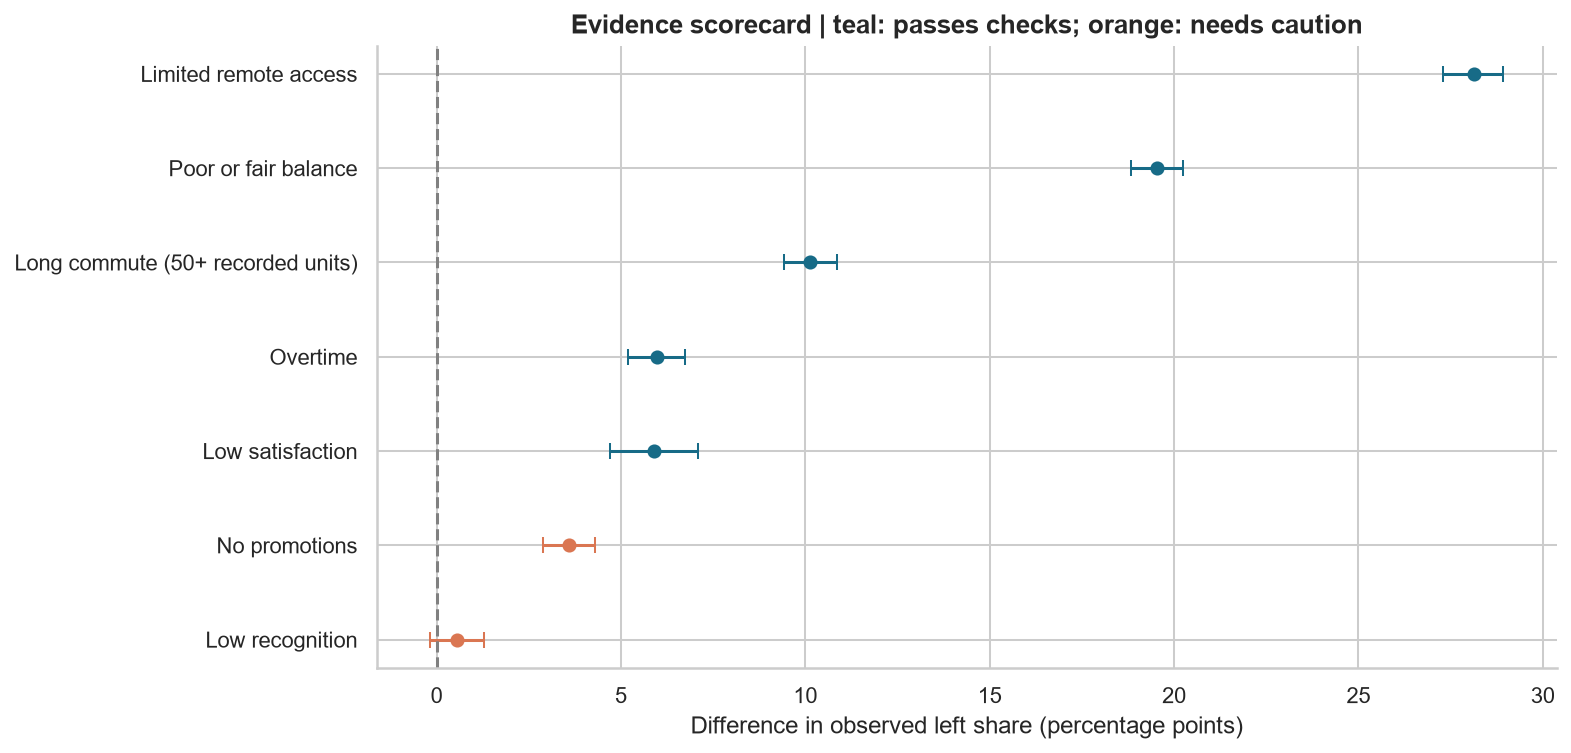

In [3]:
display(Image(filename=str(ROOT/'Reports'/'Figures'/'04_evidence_scorecard.png')))